# Getting the data ready

In [2]:
import pandas as pd

df = pd.read_csv('/content/heart.csv')

In [3]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [4]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

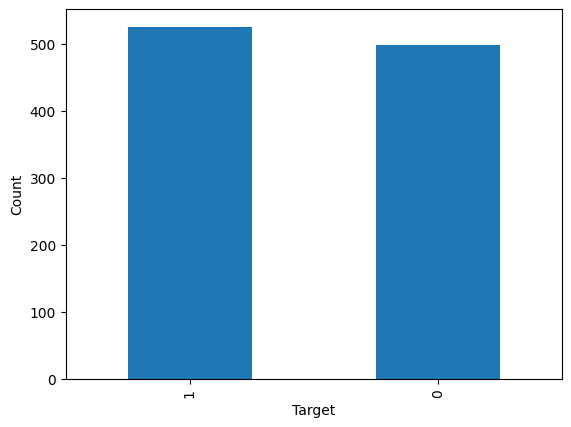

In [5]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

<Axes: >

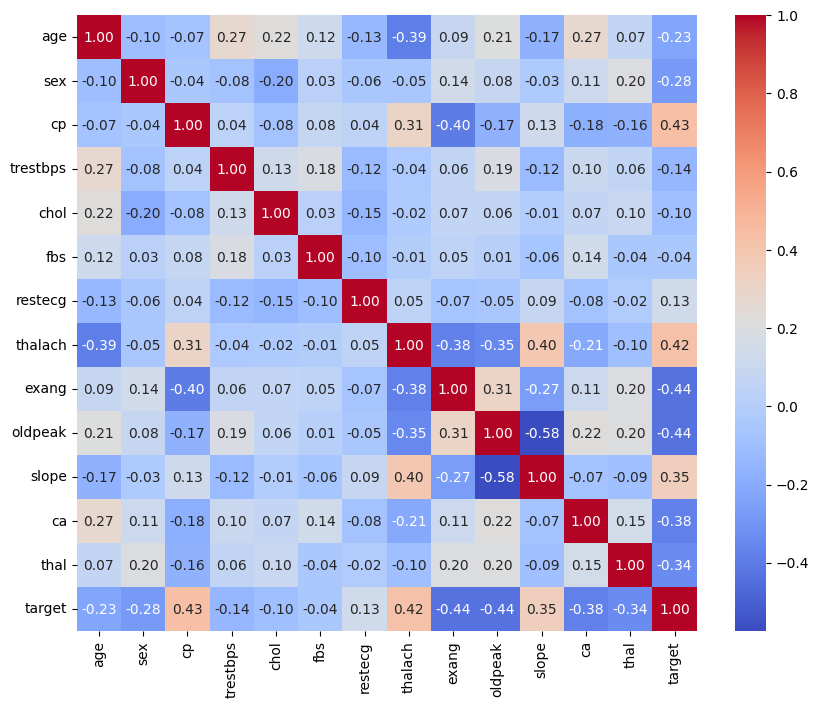

In [52]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

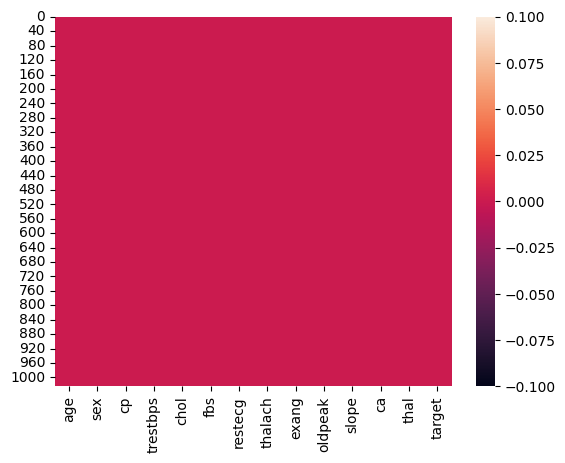

In [53]:
sns.heatmap(df.isnull())

plt.show()

In [6]:
# data preparation
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

smote = SMOTE(random_state=42) # applying SMOTE algorithm

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Biulding models

In [7]:
# with SGDClassifier
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(n_jobs=-1,
                    loss='log_loss',
                    random_state=42,
                    learning_rate = 'optimal',
                    early_stopping=True,
                    max_iter=1000,
                    eta0=0.01)

sgd.fit(X_train_scaled, y_train)
print(sgd.score(X_test_scaled, y_test), sgd.score(X_train_scaled, y_train))

0.7824675324675324 0.8256624825662483


In [8]:
# with LogisticRegression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(penalty='l2',
                        solver ='liblinear',
                        C = 1,
                        random_state=42,
                        max_iter=1000,
                        n_jobs=-1)
lr.fit(X_train_scaled, y_train)
print(lr.score(X_test_scaled, y_test), lr.score(X_train_scaled, y_train))

0.8051948051948052 0.8688981868898187


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [9]:
# with GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=1000,
                                 learning_rate=0.01,
                                 max_depth=6,
                                 random_state=42)
# scaling is not needed
gbc.fit(X_train, y_train)
print(gbc.score(X_test, y_test), gbc.score(X_train, y_train))

0.9805194805194806 1.0


In [10]:
# with GradientBoostingClassifier and HalvingRandomSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

params = {'n_estimators': [100, 500, 1000],
          'learning_rate': [0.1, 0.05, 0.01],
          'max_depth': [3, 6]}

hrs = HalvingRandomSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                            param_distributions=params,
                            n_jobs=-1,
                            cv=5,
                            scoring='accuracy',
                            factor=3,
                            min_resources=100,
                            n_candidates='exhaust').fit(X_train, y_train)

hrs.best_params_, hrs.score(X_test, y_test), hrs.score(X_train, y_train)

({'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
 0.9512987012987013,
 0.9874476987447699)

In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [12]:
# with CatBoostClassifier
from catboost import CatBoostClassifier

cbc = CatBoostClassifier(n_estimators=1000,
                         learning_rate=0.01,
                         max_depth=6,
                         l2_leaf_reg=5,
                         random_seed=42,
                         verbose=100).fit(X_train, y_train)

print(cbc.score(X_test, y_test), cbc.score(X_train, y_train)) # the best result

0:	learn: 0.6825689	total: 53.7ms	remaining: 53.6s
100:	learn: 0.2824280	total: 353ms	remaining: 3.14s
200:	learn: 0.1891457	total: 974ms	remaining: 3.87s
300:	learn: 0.1424866	total: 1.66s	remaining: 3.86s
400:	learn: 0.1142512	total: 2.47s	remaining: 3.69s
500:	learn: 0.0936534	total: 3.01s	remaining: 3s
600:	learn: 0.0775655	total: 3.57s	remaining: 2.37s
700:	learn: 0.0651318	total: 4.24s	remaining: 1.81s
800:	learn: 0.0554822	total: 4.86s	remaining: 1.21s
900:	learn: 0.0500262	total: 5.54s	remaining: 608ms
999:	learn: 0.0451358	total: 6.4s	remaining: 0us
0.9902597402597403 1.0


# Evaluation

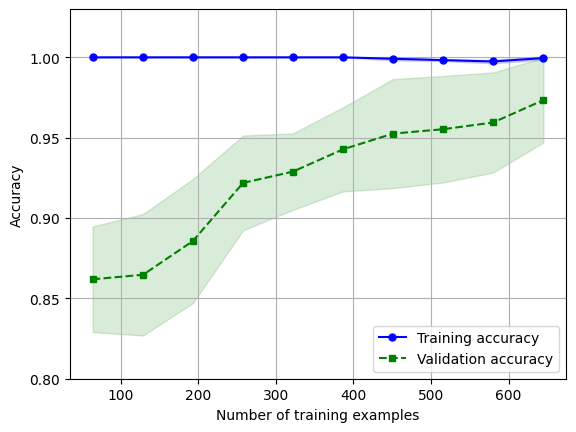

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=cbc,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=10,
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.plot(
    train_sizes,
    train_mean,
    color='blue',
    marker='o',
    markersize=5,
    label='Training accuracy'
)

plt.fill_between(
    train_sizes,
    train_mean + train_std,
    train_mean - train_std,
    alpha=0.15,
    color='blue'
)

plt.plot(
    train_sizes,
    test_mean,
    color='green',
    linestyle='--',
    marker='s',
    markersize=5,
    label='Validation accuracy'
)

plt.fill_between(
    train_sizes,
    test_mean + test_std,
    test_mean - test_std,
    alpha=0.15,
    color='green'
)

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.8, 1.03])

plt.show()

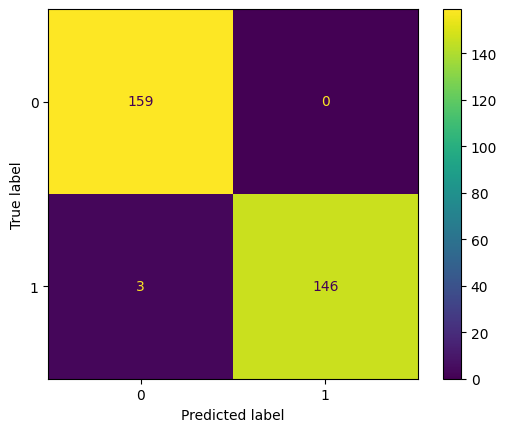

In [21]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

y_preds = cbc.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_preds)

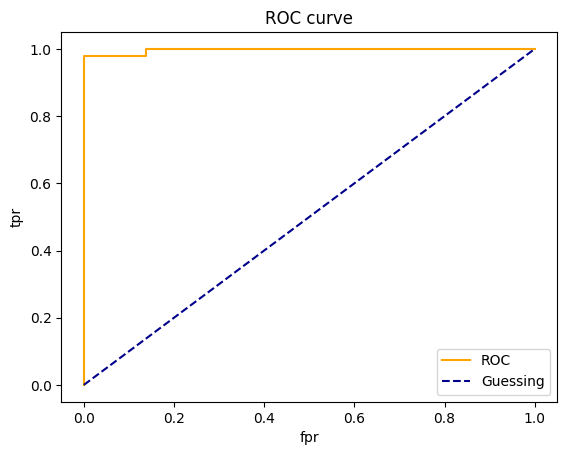

In [47]:
from sklearn.metrics import roc_curve

y_probs = cbc.predict_proba(X_test)
y_probs[:10]

y_probs_positive = y_probs[:, 1]
y_probs_positive[:10]

fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)


plt.plot(fpr, tpr, color='orange', label = 'ROC')
plt.plot([0, 1], [0, 1], color = 'darkblue', linestyle = '--', label = 'Guessing')

plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC curve')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, cbc.predict_proba(X)[:, 1])

np.float64(0.9995313821559468)

In [34]:
from sklearn.metrics import auc
auc(fpr, tpr)

np.float64(0.9972141319488412)

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       159
           1       1.00      0.98      0.99       149

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308

1.0


# Top model features

<Axes: title={'center': 'feature importance'}>

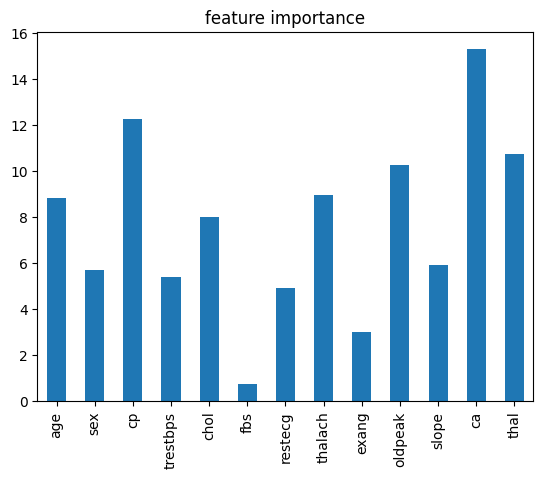

In [60]:
feature_dict = dict(zip(X.columns, cbc.feature_importances_))

feature_X = pd.DataFrame(feature_dict, index=[0])
feature_X.T.plot.bar(title='feature importance', legend=False)

# Save the model

In [64]:
import joblib
joblib.dump(cbc, 'cbc.joblib')

['cbc.joblib']